In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from typing import List, Optional

# Optional: set a clean seaborn style
sns.set_style("whitegrid")
from pathlib import Path

from scripts.preprocess import BaselinePreprocessor

# Exploratory Data Analysis: Understanding the Data Tables

This section provides an overview of the data tables available for the Home Credit Default Risk project. Before diving into numerical analysis and visualizations, it is crucial to understand the relationships between the tables, the type of information each contains, and how they can be connected to build a complete picture of each loan applicant.

## 1. Data Tables and Their Relationships

The dataset consists of one primary table (the main loan application) and six auxiliary tables that capture the applicant’s financial history from different sources. The following diagram illustrates the relationships:

```
 application_{train|test}.csv  (main table)
         │  PK: SK_ID_CURR
         │
         ├─────────────────────────────────────┐
         │                                     │
         ▼                                     ▼
   bureau.csv                          previous_application.csv
   (credit bureau records)             (previous Home Credit applications)
   FK: SK_ID_CURR                      FK: SK_ID_CURR, SK_ID_PREV
         │                                     │
         │ (SK_BUREAU_ID)                      │ (SK_ID_PREV)
         ▼                                     │
   bureau_balance.csv                          ├─── POS_CASH_balance.csv
   (monthly snapshots of bureau                │    (monthly balances of POS/cash loans)
    credits)                                   │    FK: SK_ID_CURR, SK_ID_PREV
                                               │
                                               ├─── credit_card_balance.csv
                                               │    (monthly balances of credit cards)
                                               │    FK: SK_ID_CURR, SK_ID_PREV
                                               │
                                               └─── installments_payments.csv
                                                    (payment history of previous credits)
                                                    FK: SK_ID_CURR, SK_ID_PREV
```

- **`SK_ID_CURR`** is the unique identifier for each loan in the current sample (present in the main table and all auxiliary tables).
- **`SK_ID_PREV`** identifies a specific previous credit/application from Home Credit. It is used to link a previous application to its detailed monthly balances (POS, credit card) and its payment history.
- **`SK_BUREAU_ID`** identifies a specific credit record from the Credit Bureau and links the bureau table to its monthly balances in `bureau_balance`.

## 2. Description of Each Table

### 2.1 `application_{train|test}.csv` – The Main Application Table
- **Purpose**: Contains one row per loan application in the current sample. It holds static, application-time information about the client, the loan, and some external credit scores.
- **Key column**: `SK_ID_CURR` – unique loan ID.
- **Content groups**:
  - **Target variable** (train only): `TARGET` – 1 if the client had payment difficulties, 0 otherwise.
  - **Client demographics**: Gender, age (in days relative to application), family status, number of children, education, income, employment status, occupation, etc.
  - **Loan details**: Contract type (cash/revolving), credit amount, annuity, goods price.
  - **Client assets**: Car ownership, car age, realty ownership, housing type.
  - **Region information**: Normalized population, region ratings, address match flags.
  - **Application details**: Day and hour of application, provided documents flags (2–21), phone/email provision flags.
  - **External credit scores**: `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` – normalized scores from external data sources.
  - **Building information**: Aggregated statistics (average, mode, median) about the building where the client lives (apartment size, area, elevators, entrances, construction year, etc.).
  - **Social circle defaults**: Counts of observations and defaults for 30/60 DPD in the client's social surroundings.
  - **Credit Bureau enquiries**: Number of enquiries to the Credit Bureau in the last hour, day, week, month, quarter, and year before the application.

### 2.2 `bureau.csv` – Credit Bureau Records
- **Purpose**: Contains all credit records from the Credit Bureau for the clients in the sample. Each client may have multiple previous credits reported by other financial institutions.
- **Relationship**: One `SK_ID_CURR` can be linked to multiple rows. Each row is identified by a unique `SK_BUREAU_ID`.
- **Content**:
  - **Credit status**: Active/closed status, days past due, maximal overdue amount.
  - **Timing**: Days before current application when the credit was granted, when it ended, when last updated.
  - **Financial details**: Credit amount, debt, limit, overdue amount, annuity.
  - **Credit characteristics**: Currency, type (car, cash, etc.), number of prolongations.

### 2.3 `bureau_balance.csv` – Monthly Balances of Credit Bureau Credits
- **Purpose**: Provides a month-by-month history of the credits reported in `bureau.csv`.
- **Relationship**: Linked to `bureau.csv` via `SK_BUREAU_ID`. For each credit, there is one row per month where history is available.
- **Content**:
  - `MONTHS_BALANCE`: Month relative to the current application date (e.g., -1 = most recent).
  - `STATUS`: Monthly status of the credit (C = closed, X = unknown, 0 = no DPD, 1 = DPD 1-30, 2 = DPD 31-60, …, 5 = DPD 120+ or sold/written off).

### 2.4 `POS_CASH_balance.csv` – Monthly Balances of Previous POS/Cash Loans
- **Purpose**: Contains monthly snapshots of previous point-of-sale (consumer) and cash loans that the applicant had with Home Credit.
- **Relationship**: Linked to the main table via `SK_ID_CURR` and to a specific previous credit via `SK_ID_PREV`. Multiple rows exist per previous credit (one per month).
- **Content**:
  - `MONTHS_BALANCE`: Month relative to application date.
  - `CNT_INSTALMENT`, `CNT_INSTALMENT_FUTURE`: Total and remaining instalments.
  - `NAME_CONTRACT_STATUS`: Contract status during that month (e.g., active, completed).
  - `SK_DPD`, `SK_DPD_DEF`: Days past due during the month (with and without tolerance for small amounts).

### 2.5 `credit_card_balance.csv` – Monthly Balances of Previous Credit Cards
- **Purpose**: Monthly snapshots of previous credit card accounts the applicant held with Home Credit.
- **Relationship**: Same structure as POS_CASH_balance – linked via `SK_ID_CURR` and `SK_ID_PREV`, with one row per month per credit card.
- **Content**:
  - `MONTHS_BALANCE`: Month relative to application date.
  - Balance and limit: `AMT_BALANCE`, `AMT_CREDIT_LIMIT_ACTUAL`.
  - Drawings: Amounts and counts of ATM, POS, and other drawings.
  - Payments: `AMT_PAYMENT_CURRENT`, `AMT_PAYMENT_TOTAL_CURRENT`.
  - Receivables and DPD: `AMT_RECEIVABLE_PRINCIPAL`, `SK_DPD`, `SK_DPD_DEF`.
  - `CNT_INSTALMENT_MATURE_CUM`: Number of paid instalments.
  - `NAME_CONTRACT_STATUS`: Contract status during the month.

### 2.6 `previous_application.csv` – Previous Home Credit Applications
- **Purpose**: Lists all prior loan applications the client made at Home Credit (whether approved, refused, or cancelled). One client may have multiple previous applications.
- **Relationship**: Linked via `SK_ID_CURR` and `SK_ID_PREV`. Each row is one previous application.
- **Content**:
  - **Application details**: Contract type, application amount, final credit amount, down payment, goods price, annuity, purpose.
  - **Status and decision**: Contract status (approved, cancelled, refused), rejection reason, decision date.
  - **Timing**: Days relative to current application for decision, first drawing, first/last due, and expected termination.
  - **Product specifics**: Interest rates (normalized), payment type, whether insurance was requested, portfolio, product type, channel, seller details.
  - **Flags**: Whether it was the last application for the contract, last in a day, micro cash loan, etc.

### 2.7 `installments_payments.csv` – Payment History of Previous Home Credit Credits
- **Purpose**: Records the repayment history of previous credits disbursed by Home Credit. For each previous credit, it contains one row per payment made plus one row per missed payment.
- **Relationship**: Linked via `SK_ID_CURR` and `SK_ID_PREV`.
- **Content**:
  - **Instalment identification**: `NUM_INSTALMENT_VERSION` (version of payment calendar), `NUM_INSTALMENT_NUMBER` (instalment sequence).
  - **Timing**: When the instalment was supposed to be paid (`DAYS_INSTALMENT`) and when it was actually paid (`DAYS_ENTRY_PAYMENT`), both relative to the current application date.
  - **Amounts**: `AMT_INSTALMENT` (prescribed amount), `AMT_PAYMENT` (actual amount paid).

## 3. How the Tables Connect to Answer Business Questions

- **Client creditworthiness at application time** → `application_{train|test}.csv` (demographics, income, external scores).
- **Historical credit behavior outside Home Credit** → `bureau.csv` + `bureau_balance.csv` (past loans, payment statuses).
- **Past performance within Home Credit** → `previous_application.csv` (application outcomes) + `POS_CASH_balance.csv`, `credit_card_balance.csv`, `installments_payments.csv` (detailed repayment behavior).

This structured view allows us to build a comprehensive feature set that captures both static client characteristics and dynamic payment behavior over time.

In [3]:
class EDAHelper:
    """
    A collection of exploratory data analysis functions.
    Designed to work with any pandas DataFrame, including those
    loaded by BaselinePreprocessor.
    """

    @staticmethod
    def show_column_info(df: pd.DataFrame) -> None:
        """
        1. Displays column types and counts per type.
        """
        logger.info("===== Column Data Types =====")
        dtypes_summary = df.dtypes.value_counts()
        print(dtypes_summary)
        print("\n")
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
        logger.info(f"Numerical columns ({len(numeric_cols)}): {numeric_cols}")
        logger.info(f"Categorical/string columns ({len(categorical_cols)}): {categorical_cols}")

    @staticmethod
    def show_missing_values(df: pd.DataFrame) -> pd.DataFrame:
        """
        2. Shows total NaN counts and returns a sorted summary.
        """
        logger.info("===== Missing Values =====")
        total = df.shape[0]
        missing = df.isnull().sum()
        missing_perc = (missing / total * 100).round(2)
        missing_df = pd.DataFrame({
            'Column': missing.index,
            'Missing': missing.values,
            'Percentage': missing_perc.values
        })
        missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
        if missing_df.empty:
            logger.info("No missing values found.")
            return missing_df

        logger.info(f"Total columns with missing values: {len(missing_df)}")
        print(missing_df.to_string(index=False))
        return missing_df

    @staticmethod
    def show_numeric_stats(df: pd.DataFrame) -> None:
        """
        3. Prints scale statistics (min, max, mean, std, percentiles) for numeric columns.
        """
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) == 0:
            logger.info("No numeric columns found.")
            return

        logger.info("===== Numeric Column Statistics =====")
        stats = df[numeric_cols].describe().transpose()
        # Add median, skewness, and kurtosis for deeper insight
        stats['median'] = df[numeric_cols].median()
        stats['skew'] = df[numeric_cols].skew()
        stats['kurtosis'] = df[numeric_cols].kurtosis()
        print(stats.round(2).to_string())

    @staticmethod
    def plot_distribution(df: pd.DataFrame, column: str) -> None:
        """
        4. Plot distribution of a single column.
           Works for numeric (histogram + KDE) and categorical (barplot).
           Use this to check for imbalance (e.g., TARGET).
        """
        if column not in df.columns:
            logger.error(f"Column '{column}' not found in DataFrame.")
            return

        plt.figure(figsize=(8, 5))
        if df[column].dtype in [np.float64, np.int64, 'float32', 'int32']:
            # Numeric
            sns.histplot(df[column].dropna(), kde=True, bins=50, color='steelblue')
            plt.title(f'Distribution of {column}')
            plt.xlabel(column)
            plt.ylabel('Frequency')
        else:
            # Categorical
            value_counts = df[column].value_counts(dropna=False)
            sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette='viridis')
            plt.xticks(rotation=45, ha='right')
            plt.title(f'Distribution of {column}')
            plt.xlabel(column)
            plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def boxplot_numeric(df: pd.DataFrame, columns: Optional[List[str]] = None,
                        max_cols_per_fig: int = 6) -> None:
        """
        5. Creates box plots for all (or selected) numeric columns to detect outliers.
           Splits into multiple figures if there are many columns.
        """
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if columns:
            numeric_cols = [c for c in columns if c in numeric_cols]
        if len(numeric_cols) == 0:
            logger.info("No numeric columns to plot.")
            return

        logger.info(f"Plotting box plots for {len(numeric_cols)} numeric columns.")
        for i in range(0, len(numeric_cols), max_cols_per_fig):
            batch = numeric_cols[i:i + max_cols_per_fig]
            fig, axes = plt.subplots(1, len(batch), figsize=(len(batch) * 3.5, 5))
            if len(batch) == 1:
                axes = [axes]  # ensure iterable
            for col, ax in zip(batch, axes):
                sns.boxplot(y=df[col], ax=ax, color='lightcoral')
                ax.set_title(col)
                ax.set_ylabel('')
            plt.suptitle(f'Box Plots (Outliers) – Group {i // max_cols_per_fig + 1}')
            plt.tight_layout()
            plt.show()

In [4]:
preprocessor = BaselinePreprocessor()
eda = EDAHelper()
data_dir = "../../data/"

2026-06-13 18:21:04.979 | INFO     | scripts.preprocess:__init__:30 - Initialized BaselinePreprocessor with random_state=42


### application_train.csv

2026-06-12 20:47:45.153 | INFO     | __main__:<module>:4 - ============================================================
2026-06-12 20:47:45.154 | INFO     | __main__:<module>:5 - EDA: application_train.csv
2026-06-12 20:47:45.155 | INFO     | __main__:<module>:6 - ============================================================
2026-06-12 20:47:45.155 | INFO     | scripts.preprocess:load_data:30 - Attempting to load data from ../../data/application_train.csv
2026-06-12 20:47:46.704 | INFO     | scripts.preprocess:load_data:32 - Successfully loaded data with shape (307511, 122)
2026-06-12 20:47:46.704 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, 

float64    65
int64      41
str        16
Name: count, dtype: int64


                      Column  Missing  Percentage
             COMMONAREA_MEDI   214865       69.87
              COMMONAREA_AVG   214865       69.87
             COMMONAREA_MODE   214865       69.87
    NONLIVINGAPARTMENTS_MEDI   213514       69.43
    NONLIVINGAPARTMENTS_MODE   213514       69.43
     NONLIVINGAPARTMENTS_AVG   213514       69.43
          FONDKAPREMONT_MODE   210295       68.39
       LIVINGAPARTMENTS_MODE   210199       68.35
       LIVINGAPARTMENTS_MEDI   210199       68.35
        LIVINGAPARTMENTS_AVG   210199       68.35
              FLOORSMIN_MODE   208642       67.85
              FLOORSMIN_MEDI   208642       67.85
               FLOORSMIN_AVG   208642       67.85
            YEARS_BUILD_MODE   204488       66.50
            YEARS_BUILD_MEDI   204488       66.50
             YEARS_BUILD_AVG   204488       66.50
                 OWN_CAR_AGE   202929       65.99
                LANDAREA_AVG  

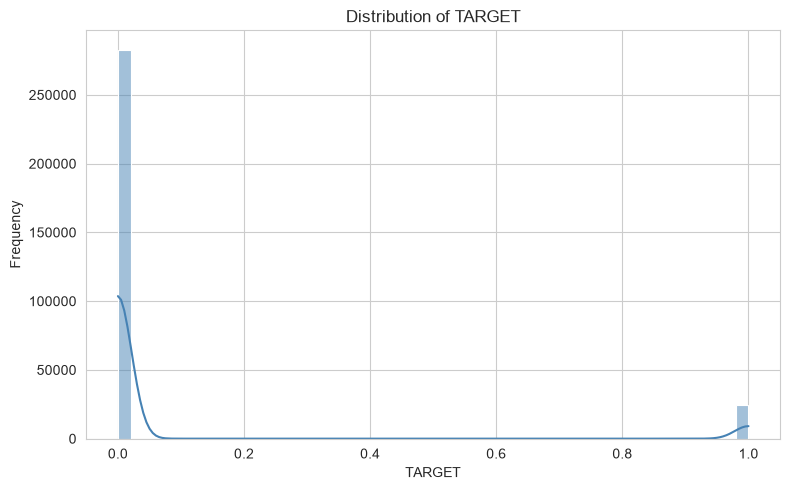

2026-06-12 20:47:48.698 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 4 numeric columns.


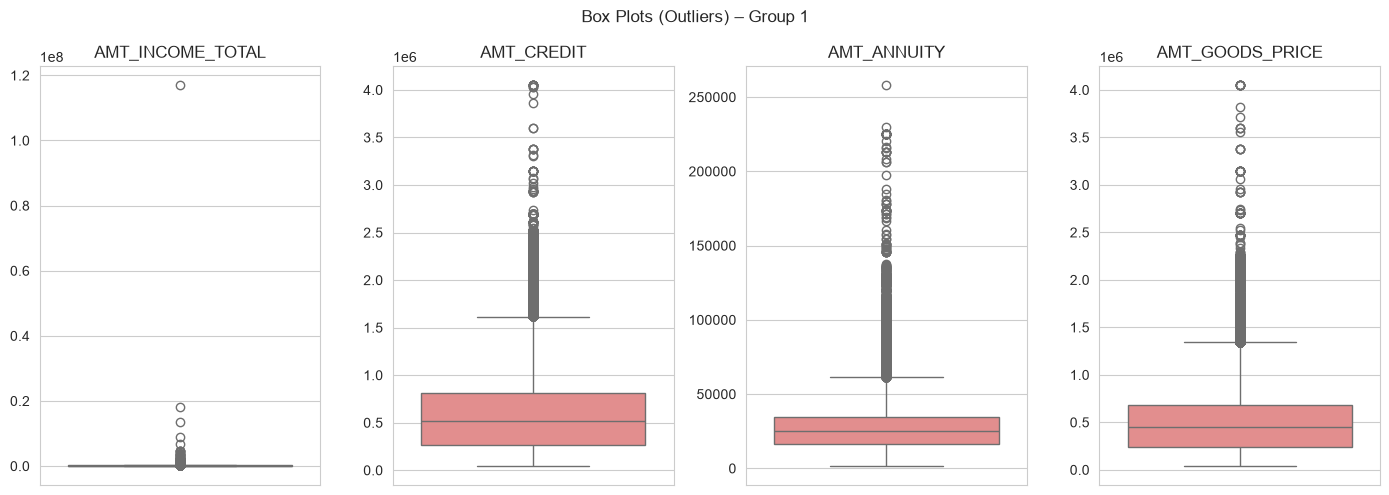

2026-06-12 20:47:49.625 | INFO     | __main__:<module>:29 - application_train.csv EDA completed.


In [14]:
# -----------------------------------------------------------------
# application_train.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: application_train.csv")
logger.info("=" * 60)

df_app_train = preprocessor.load_data(f"{data_dir}application_train.csv")

# 1. Column types
eda.show_column_info(df_app_train)

# 2. Missing values (sorted)
missing_app_train = eda.show_missing_values(df_app_train)

# 3. Numeric statistics (scale, skew, kurtosis)
eda.show_numeric_stats(df_app_train)

# 4. Target imbalance check
eda.plot_distribution(df_app_train, 'TARGET')

# 5. Outlier boxes for key financial features
key_num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
eda.boxplot_numeric(df_app_train, columns=key_num_cols)

# Optionally, boxplots for ALL numeric columns (will create multiple figures)
# eda.boxplot_numeric(df_app_train)

logger.info("application_train.csv EDA completed.")

2026-06-12 20:48:24.006 | INFO     | __main__:<module>:4 - ============================================================
2026-06-12 20:48:24.007 | INFO     | __main__:<module>:5 - EDA: application_test.csv
2026-06-12 20:48:24.008 | INFO     | __main__:<module>:6 - ============================================================
2026-06-12 20:48:24.008 | INFO     | scripts.preprocess:load_data:30 - Attempting to load data from ../../data/application_test.csv
2026-06-12 20:48:24.276 | INFO     | scripts.preprocess:load_data:32 - Successfully loaded data with shape (48744, 121)
2026-06-12 20:48:24.276 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or 

float64    65
int64      40
str        16
Name: count, dtype: int64


                      Column  Missing  Percentage
             COMMONAREA_MODE    33495       68.72
             COMMONAREA_MEDI    33495       68.72
              COMMONAREA_AVG    33495       68.72
    NONLIVINGAPARTMENTS_MEDI    33347       68.41
     NONLIVINGAPARTMENTS_AVG    33347       68.41
    NONLIVINGAPARTMENTS_MODE    33347       68.41
          FONDKAPREMONT_MODE    32797       67.28
       LIVINGAPARTMENTS_MODE    32780       67.25
       LIVINGAPARTMENTS_MEDI    32780       67.25
        LIVINGAPARTMENTS_AVG    32780       67.25
              FLOORSMIN_MEDI    32466       66.61
              FLOORSMIN_MODE    32466       66.61
               FLOORSMIN_AVG    32466       66.61
                 OWN_CAR_AGE    32312       66.29
             YEARS_BUILD_AVG    31818       65.28
            YEARS_BUILD_MEDI    31818       65.28
            YEARS_BUILD_MODE    31818       65.28
               LANDAREA_MODE  

2026-06-12 20:48:24.581 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 3 numeric columns.


                                count       mean        std        min        25%        50%        75%         max     median    skew  kurtosis
SK_ID_CURR                    48744.0  277796.68  103169.55  100001.00  188557.75  277549.00  367555.50   456250.00  277549.00    0.01     -1.21
CNT_CHILDREN                  48744.0       0.40       0.71       0.00       0.00       0.00       1.00       20.00       0.00    2.37     17.64
AMT_INCOME_TOTAL              48744.0  178431.81  101522.59   26941.50  112500.00  157500.00  225000.00  4410000.00  157500.00    5.30    111.23
AMT_CREDIT                    48744.0  516740.44  365397.00   45000.00  260640.00  450000.00  675000.00  2245500.00  450000.00    1.65      3.34
AMT_ANNUITY                   48720.0   29426.24   16016.37    2295.00   17973.00   26199.00   37390.50   180576.00   26199.00    1.47      5.01
AMT_GOODS_PRICE               48744.0  462618.84  336710.22   45000.00  225000.00  396000.00  630000.00  2245500.00  396000.00    

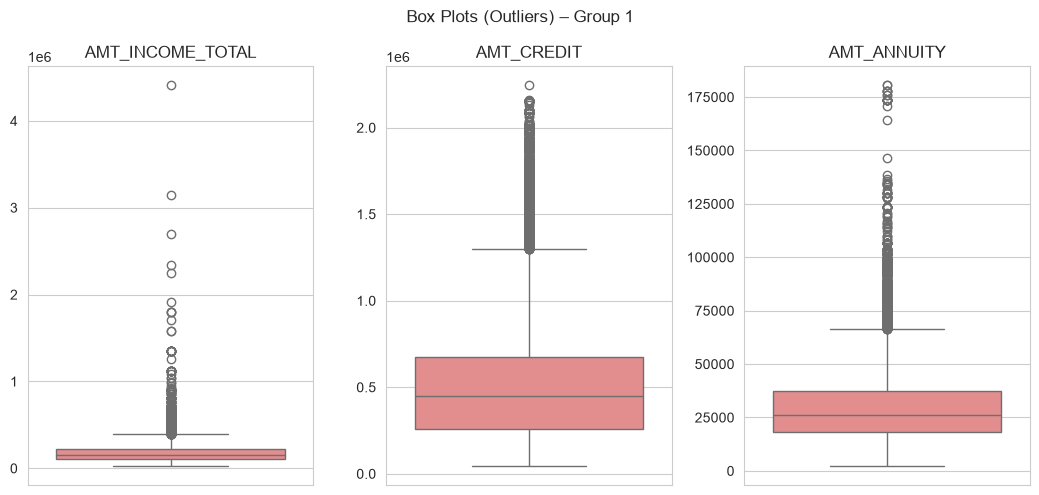

2026-06-12 20:48:24.782 | INFO     | __main__:<module>:19 - application_test.csv EDA completed.


In [15]:
# -----------------------------------------------------------------
# application_test.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: application_test.csv")
logger.info("=" * 60)

df_app_test = preprocessor.load_data(f"{data_dir}application_test.csv")

eda.show_column_info(df_app_test)
missing_app_test = eda.show_missing_values(df_app_test)
eda.show_numeric_stats(df_app_test)

# No TARGET column; distribution of other key columns can be checked:
# eda.plot_distribution(df_app_test, 'AMT_INCOME_TOTAL')

eda.boxplot_numeric(df_app_test, columns=['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY'])

logger.info("application_test.csv EDA completed.")

2026-06-12 20:48:43.050 | INFO     | __main__:<module>:4 - ============================================================
2026-06-12 20:48:43.051 | INFO     | __main__:<module>:5 - EDA: bureau.csv
2026-06-12 20:48:43.052 | INFO     | __main__:<module>:6 - ============================================================
2026-06-12 20:48:43.052 | INFO     | scripts.preprocess:load_data:30 - Attempting to load data from ../../data/bureau.csv
2026-06-12 20:48:44.220 | INFO     | scripts.preprocess:load_data:32 - Successfully loaded data with shape (1716428, 17)
2026-06-12 20:48:44.221 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to rem

float64    8
int64      6
str        3
Name: count, dtype: int64


                Column  Missing  Percentage
           AMT_ANNUITY  1226791       71.47
AMT_CREDIT_MAX_OVERDUE  1124488       65.51
     DAYS_ENDDATE_FACT   633653       36.92
  AMT_CREDIT_SUM_LIMIT   591780       34.48
   AMT_CREDIT_SUM_DEBT   257669       15.01
   DAYS_CREDIT_ENDDATE   105553        6.15
        AMT_CREDIT_SUM       13        0.00
                            count        mean         std         min         25%        50%         75%           max     median    skew   kurtosis
SK_ID_CURR              1716428.0   278214.93   102938.56   100001.00   188866.75   278055.0   367426.00  4.562550e+05   278055.0    0.00      -1.20
SK_ID_BUREAU            1716428.0  5924434.49   532265.73  5000000.00  5463953.75  5926303.5  6385681.25  6.843457e+06  5926303.5   -0.01      -1.20
DAYS_CREDIT             1716428.0    -1142.11      795.16    -2922.00    -1666.00     -987.0     -474.00  0.000000e+00     -987.0   -0

/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette='viridis')


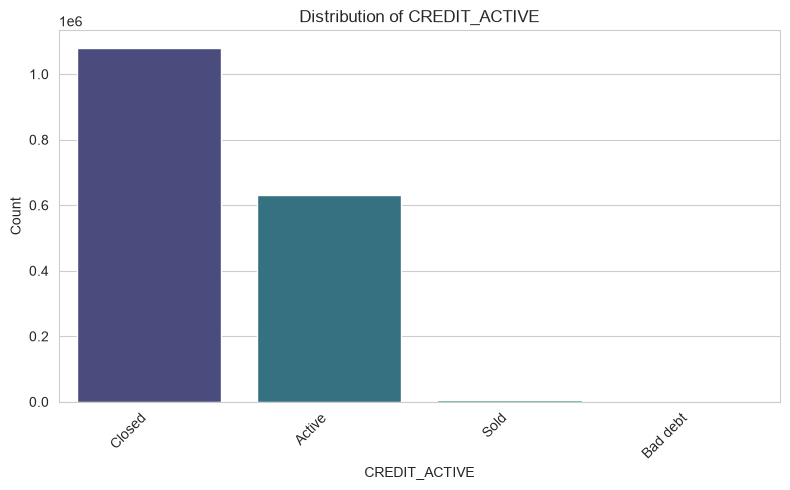

2026-06-12 20:48:45.568 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 11 numeric columns.


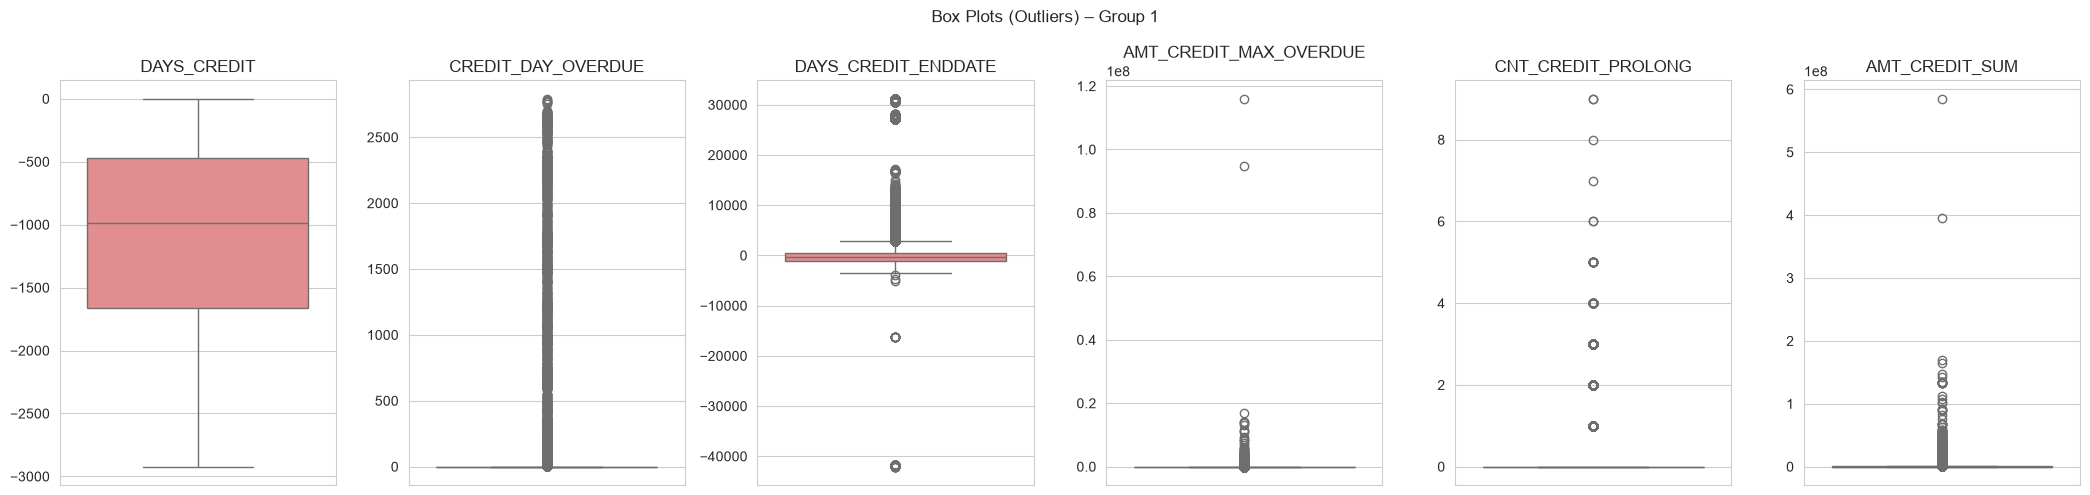

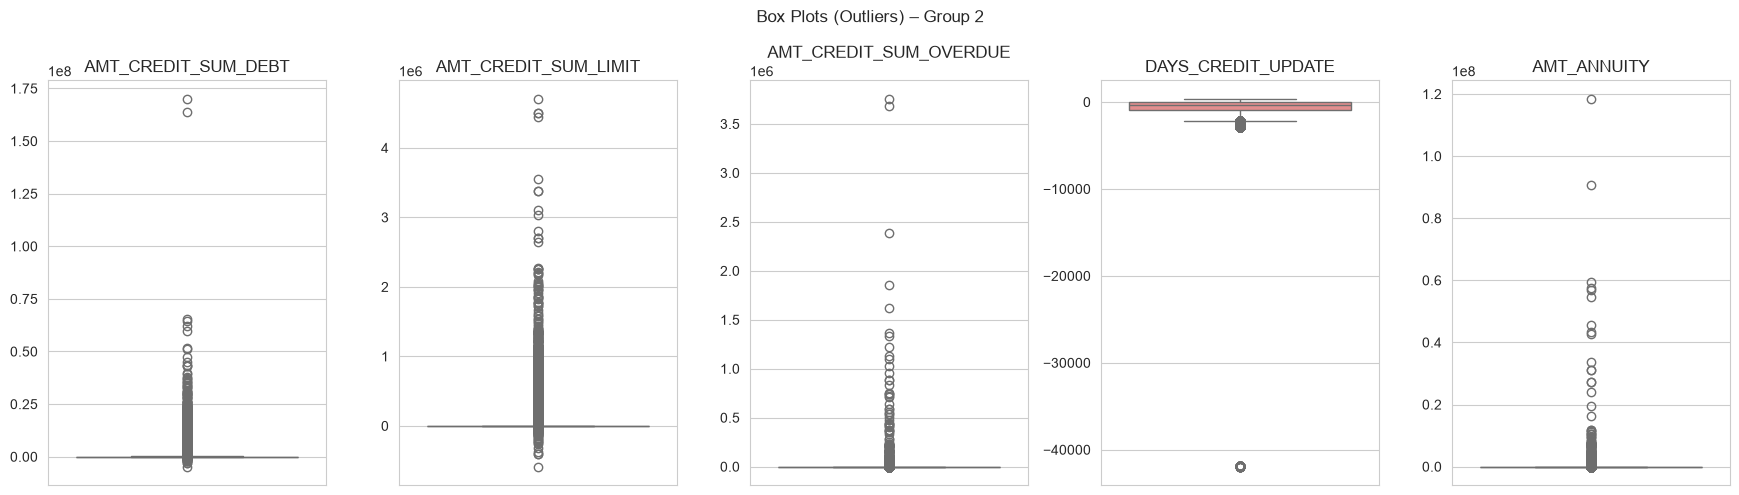

2026-06-12 20:48:57.855 | INFO     | __main__:<module>:24 - bureau.csv EDA completed.


In [16]:
# -----------------------------------------------------------------
# bureau.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: bureau.csv")
logger.info("=" * 60)

df_bureau = preprocessor.load_data(f"{data_dir}bureau.csv")

eda.show_column_info(df_bureau)
missing_bureau = eda.show_missing_values(df_bureau)
eda.show_numeric_stats(df_bureau)

# Distribution of a categorical column (e.g., CREDIT_ACTIVE)
eda.plot_distribution(df_bureau, 'CREDIT_ACTIVE')

# Boxplots on numeric columns (skip ID hashed columns like SK_ID_CURR, SK_BUREAU_ID)
bureau_num_cols = ['DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
                   'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
                   'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
                   'AMT_CREDIT_SUM_OVERDUE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']
eda.boxplot_numeric(df_bureau, columns=bureau_num_cols)

logger.info("bureau.csv EDA completed.")

2026-06-12 20:49:12.766 | INFO     | __main__:<module>:4 - ============================================================
2026-06-12 20:49:12.767 | INFO     | __main__:<module>:5 - EDA: bureau_balance.csv
2026-06-12 20:49:12.768 | INFO     | __main__:<module>:6 - ============================================================
2026-06-12 20:49:12.768 | INFO     | scripts.preprocess:load_data:30 - Attempting to load data from ../../data/bureau_balance.csv
2026-06-12 20:49:15.883 | INFO     | scripts.preprocess:load_data:32 - Successfully loaded data with shape (27299925, 3)
2026-06-12 20:49:15.883 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to 

int64    2
str      1
Name: count, dtype: int64




2026-06-12 20:49:16.436 | INFO     | __main__:show_missing_values:38 - No missing values found.
2026-06-12 20:49:16.436 | INFO     | __main__:show_numeric_stats:55 - ===== Numeric Column Statistics =====


                     count        mean        std        min        25%        50%        75%        max     median  skew  kurtosis
SK_ID_BUREAU    27299925.0  6036297.33  492348.86  5001709.0  5730933.0  6070821.0  6431951.0  6842888.0  6070821.0 -0.37     -0.74
MONTHS_BALANCE  27299925.0      -30.74      23.86      -96.0      -46.0      -25.0      -11.0        0.0      -25.0 -0.76     -0.32


/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette='viridis')


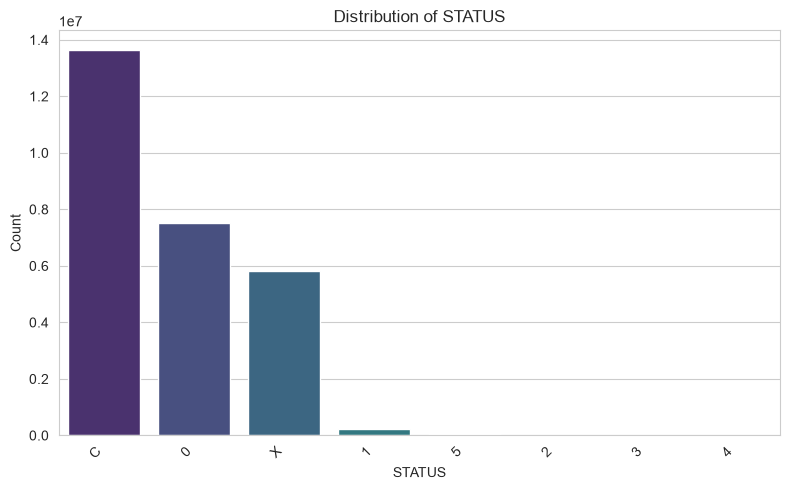

2026-06-12 20:49:18.377 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 1 numeric columns.


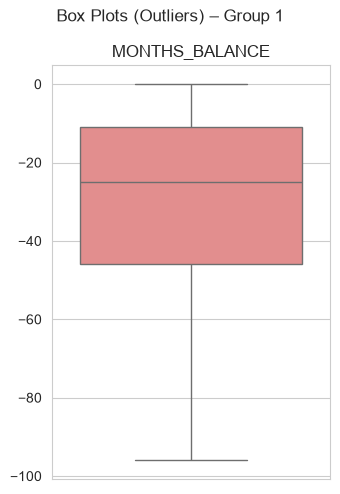

2026-06-12 20:49:35.251 | INFO     | __main__:<module>:20 - bureau_balance.csv EDA completed.


In [17]:
# -----------------------------------------------------------------
# bureau_balance.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: bureau_balance.csv")
logger.info("=" * 60)

df_bb = preprocessor.load_data(f"{data_dir}bureau_balance.csv")

eda.show_column_info(df_bb)
missing_bb = eda.show_missing_values(df_bb)
eda.show_numeric_stats(df_bb)

# Distribution of STATUS (categorical, key DPD information)
eda.plot_distribution(df_bb, 'STATUS')

# Numeric column: MONTHS_BALANCE is the only numeric here
eda.boxplot_numeric(df_bb, columns=['MONTHS_BALANCE'])

logger.info("bureau_balance.csv EDA completed.")

2026-06-12 20:50:02.385 | INFO     | __main__:<module>:4 - ============================================================
2026-06-12 20:50:02.386 | INFO     | __main__:<module>:5 - EDA: POS_CASH_balance.csv
2026-06-12 20:50:02.387 | INFO     | __main__:<module>:6 - ============================================================
2026-06-12 20:50:02.387 | INFO     | scripts.preprocess:load_data:30 - Attempting to load data from ../../data/POS_CASH_balance.csv
2026-06-12 20:50:05.276 | INFO     | scripts.preprocess:load_data:32 - Successfully loaded data with shape (10001358, 8)
2026-06-12 20:50:05.277 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or

int64      5
float64    2
str        1
Name: count, dtype: int64




2026-06-12 20:50:05.509 | INFO     | __main__:show_missing_values:41 - Total columns with missing values: 2
2026-06-12 20:50:05.510 | INFO     | __main__:show_numeric_stats:55 - ===== Numeric Column Statistics =====


               Column  Missing  Percentage
CNT_INSTALMENT_FUTURE    26087        0.26
       CNT_INSTALMENT    26071        0.26
                            count        mean        std        min        25%        50%        75%        max     median   skew  kurtosis
SK_ID_PREV             10001358.0  1903216.60  535846.53  1000001.0  1434405.0  1896565.0  2368963.0  2843499.0  1896565.0   0.04     -1.22
SK_ID_CURR             10001358.0   278403.86  102763.75   100001.0   189550.0   278654.0   367429.0   456255.0   278654.0  -0.00     -1.20
MONTHS_BALANCE         10001358.0      -35.01      26.07      -96.0      -54.0      -28.0      -13.0       -1.0      -28.0  -0.67     -0.71
CNT_INSTALMENT          9975287.0       17.09      12.00        1.0       10.0       12.0       24.0       92.0       12.0   1.60      2.45
CNT_INSTALMENT_FUTURE   9975271.0       10.48      11.11        0.0        3.0        7.0       14.0       85.0        7.0   1.85      3.71
SK_DPD                 10001358

/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette='viridis')


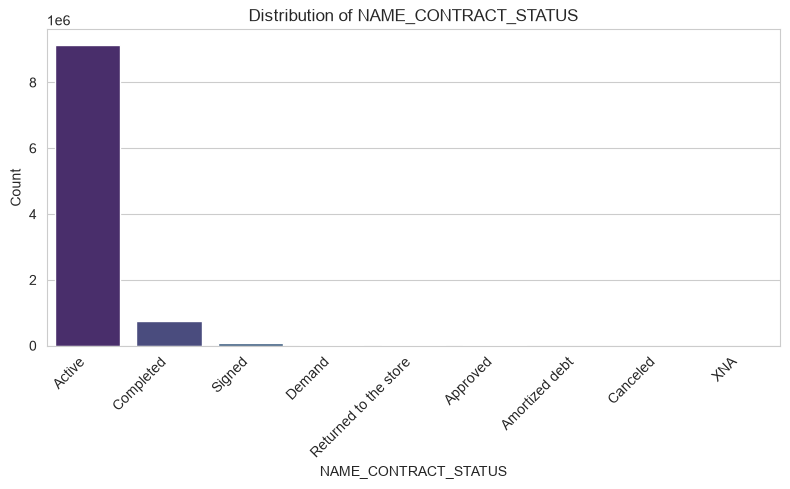

2026-06-12 20:50:08.607 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 5 numeric columns.


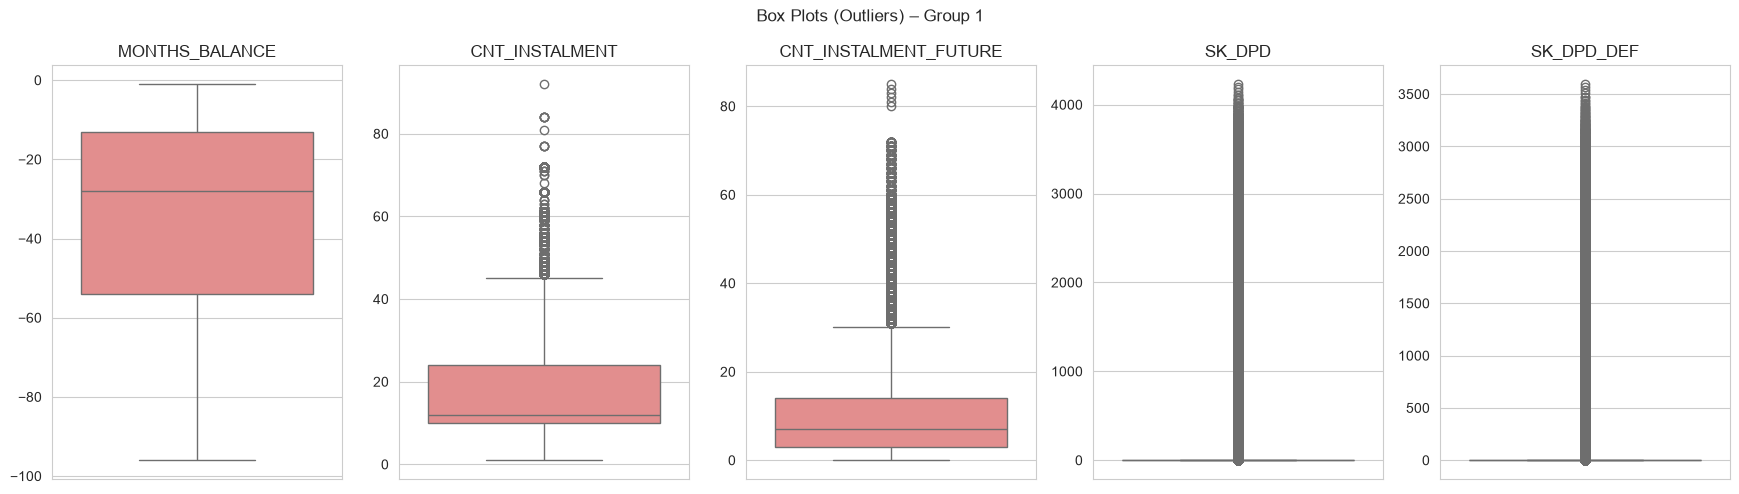

2026-06-12 20:50:40.981 | INFO     | __main__:<module>:22 - POS_CASH_balance.csv EDA completed.


In [18]:
# -----------------------------------------------------------------
# POS_CASH_balance.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: POS_CASH_balance.csv")
logger.info("=" * 60)

df_pos = preprocessor.load_data(f"{data_dir}POS_CASH_balance.csv")

eda.show_column_info(df_pos)
missing_pos = eda.show_missing_values(df_pos)
eda.show_numeric_stats(df_pos)

# Contract status distribution
eda.plot_distribution(df_pos, 'NAME_CONTRACT_STATUS')

# Numeric columns (excluding ID / flag columns)
pos_num_cols = ['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE',
                'SK_DPD', 'SK_DPD_DEF']
eda.boxplot_numeric(df_pos, columns=pos_num_cols)

logger.info("POS_CASH_balance.csv EDA completed.")

2026-06-12 20:50:54.391 | INFO     | __main__:<module>:4 - ============================================================
2026-06-12 20:50:54.392 | INFO     | __main__:<module>:5 - EDA: credit_card_balance.csv
2026-06-12 20:50:54.393 | INFO     | __main__:<module>:6 - ============================================================
2026-06-12 20:50:54.394 | INFO     | scripts.preprocess:load_data:30 - Attempting to load data from ../../data/credit_card_balance.csv
2026-06-12 20:50:57.557 | INFO     | scripts.preprocess:load_data:32 - Successfully loaded data with shape (3840312, 23)
2026-06-12 20:50:57.557 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select th

float64    15
int64       7
str         1
Name: count, dtype: int64


                    Column  Missing  Percentage
       AMT_PAYMENT_CURRENT   767988       20.00
  AMT_DRAWINGS_ATM_CURRENT   749816       19.52
AMT_DRAWINGS_OTHER_CURRENT   749816       19.52
  AMT_DRAWINGS_POS_CURRENT   749816       19.52
  CNT_DRAWINGS_ATM_CURRENT   749816       19.52
CNT_DRAWINGS_OTHER_CURRENT   749816       19.52
  CNT_DRAWINGS_POS_CURRENT   749816       19.52
   AMT_INST_MIN_REGULARITY   305236        7.95
 CNT_INSTALMENT_MATURE_CUM   305236        7.95
                                count        mean        std         min         25%        50%         75%         max     median   skew  kurtosis
SK_ID_PREV                  3840312.0  1904503.59  536469.47  1000018.00  1434385.00  1897122.0  2369327.75  2843496.00  1897122.0   0.04     -1.22
SK_ID_CURR                  3840312.0   278324.21  102704.48   100006.00   189517.00   278396.0   367580.00   456250.00   278396.0  -0.00     -1.20
MONTHS

/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette='viridis')


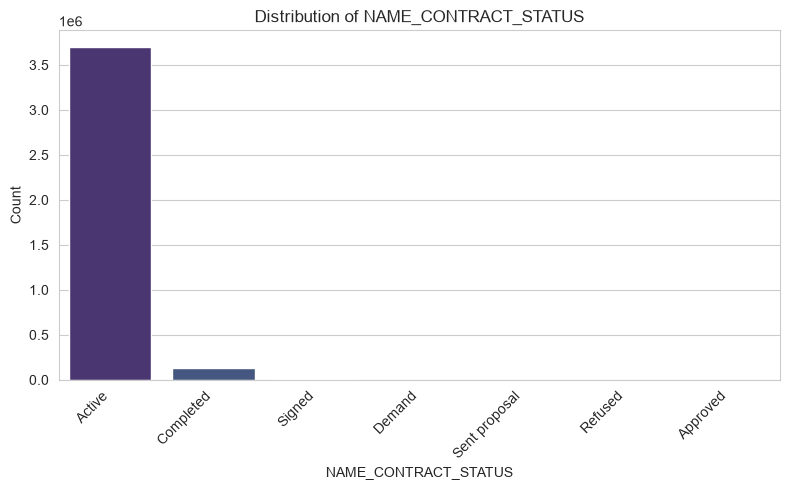

2026-06-12 20:51:01.507 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 20 numeric columns.


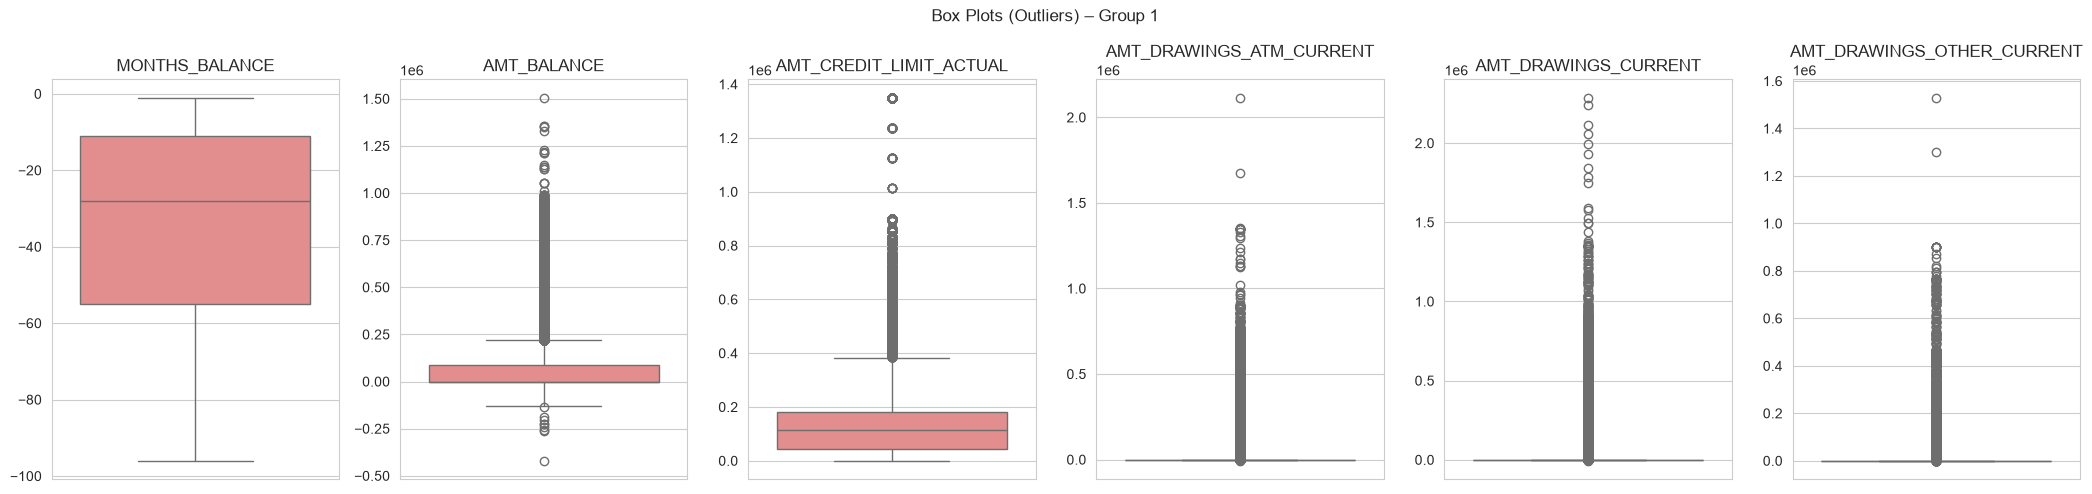

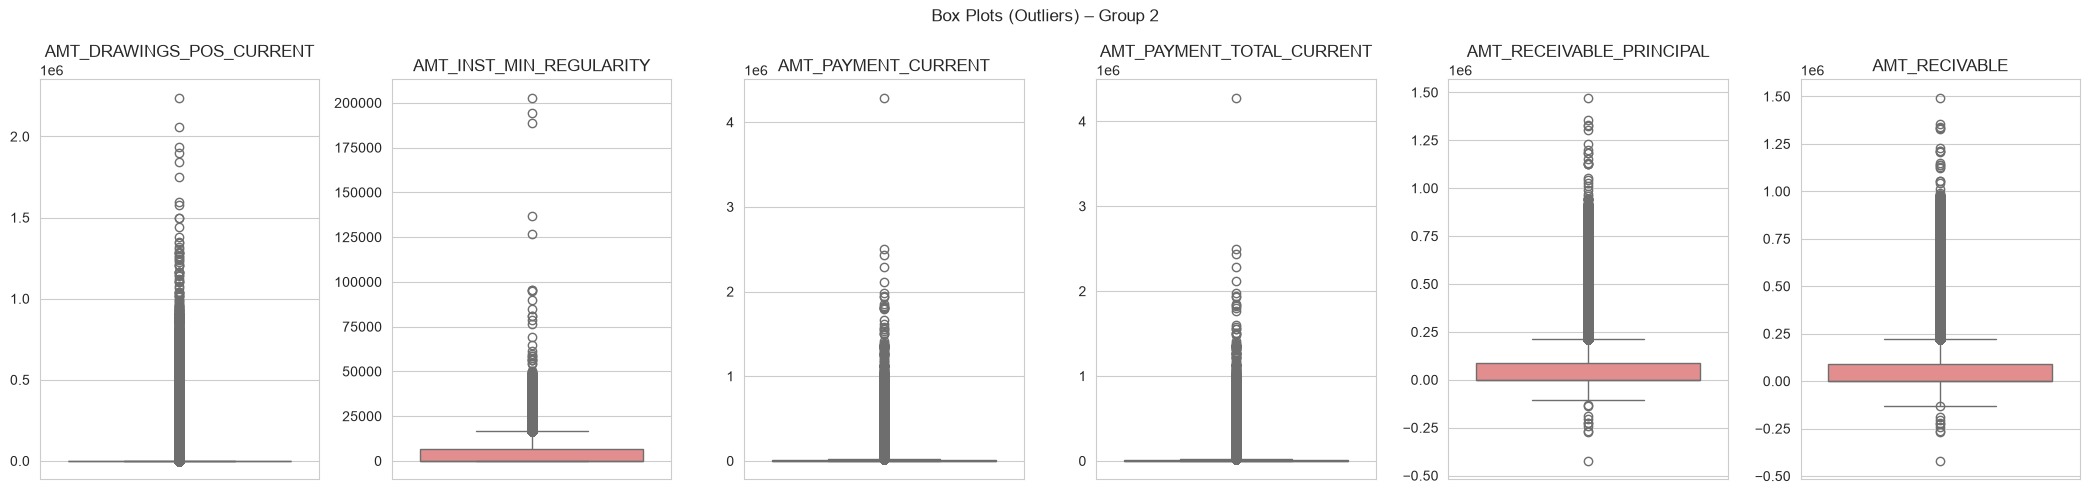

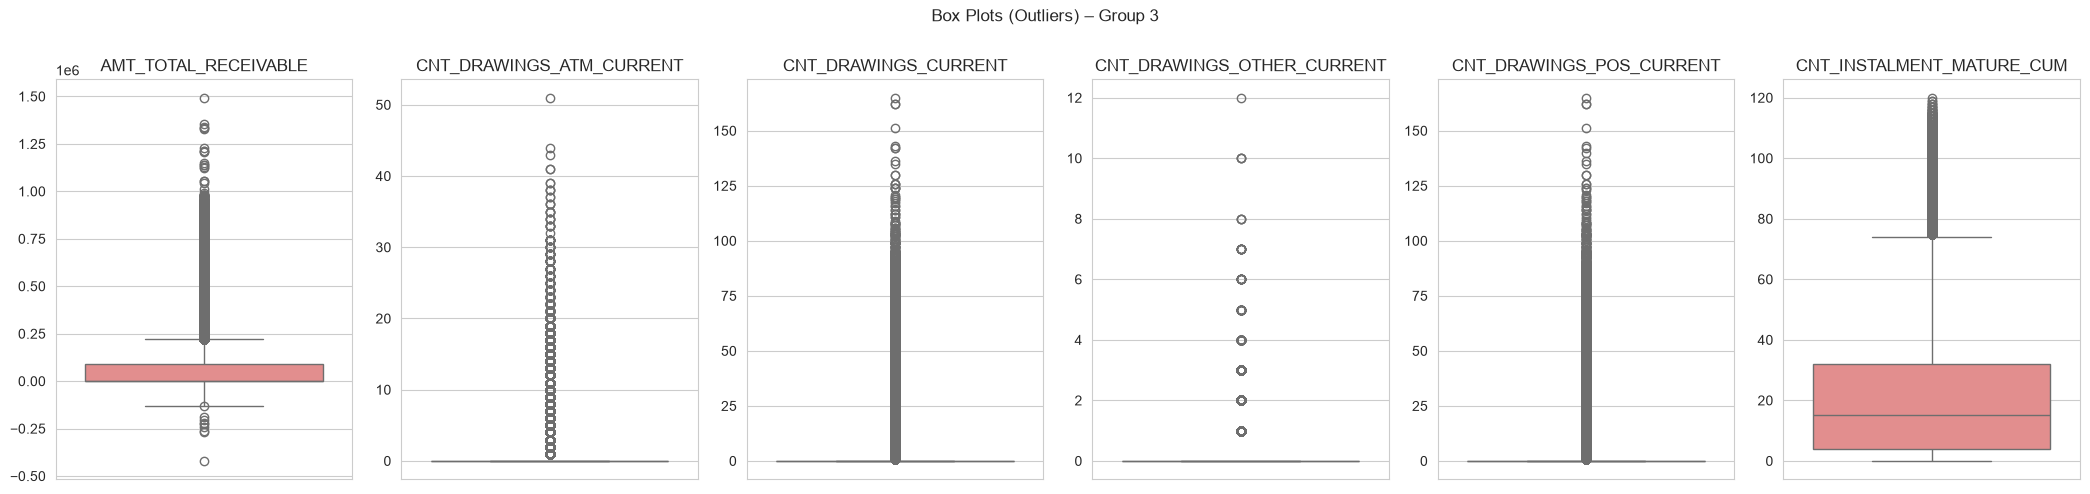

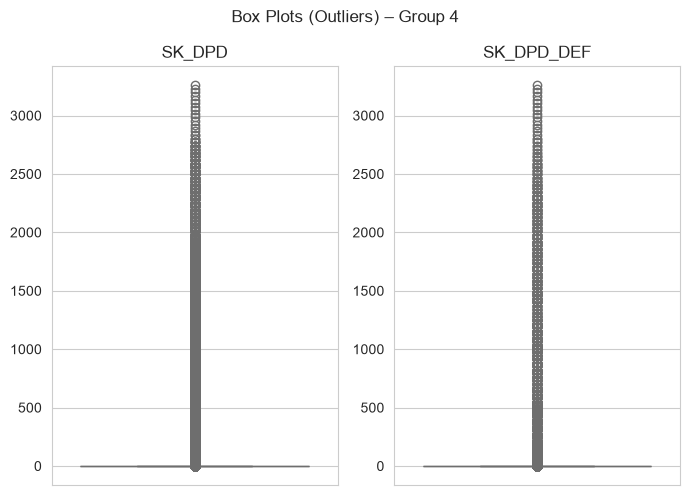

2026-06-12 20:51:51.822 | INFO     | __main__:<module>:28 - credit_card_balance.csv EDA completed.


In [19]:
# -----------------------------------------------------------------
# credit_card_balance.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: credit_card_balance.csv")
logger.info("=" * 60)

df_cc = preprocessor.load_data(f"{data_dir}credit_card_balance.csv")

eda.show_column_info(df_cc)
missing_cc = eda.show_missing_values(df_cc)
eda.show_numeric_stats(df_cc)

# Contract status distribution
eda.plot_distribution(df_cc, 'NAME_CONTRACT_STATUS')

cc_num_cols = ['MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL',
               'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT',
               'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT',
               'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT',
               'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL',
               'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
               'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
               'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
               'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF']
eda.boxplot_numeric(df_cc, columns=cc_num_cols)

logger.info("credit_card_balance.csv EDA completed.")

2026-06-12 20:51:51.828 | INFO     | __main__:<module>:4 - ============================================================
2026-06-12 20:51:51.828 | INFO     | __main__:<module>:5 - EDA: previous_application.csv
2026-06-12 20:51:51.829 | INFO     | __main__:<module>:6 - ============================================================
2026-06-12 20:51:51.829 | INFO     | scripts.preprocess:load_data:30 - Attempting to load data from ../../data/previous_application.csv
2026-06-12 20:51:55.191 | INFO     | scripts.preprocess:load_data:32 - Successfully loaded data with shape (1670214, 37)
2026-06-12 20:51:55.191 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select 

str        16
float64    15
int64       6
Name: count, dtype: int64




2026-06-12 20:51:55.813 | INFO     | __main__:show_missing_values:41 - Total columns with missing values: 16
2026-06-12 20:51:55.814 | INFO     | __main__:show_numeric_stats:55 - ===== Numeric Column Statistics =====


                   Column  Missing  Percentage
    RATE_INTEREST_PRIMARY  1664263       99.64
 RATE_INTEREST_PRIVILEGED  1664263       99.64
         AMT_DOWN_PAYMENT   895844       53.64
        RATE_DOWN_PAYMENT   895844       53.64
          NAME_TYPE_SUITE   820405       49.12
       DAYS_FIRST_DRAWING   673065       40.30
           DAYS_FIRST_DUE   673065       40.30
DAYS_LAST_DUE_1ST_VERSION   673065       40.30
            DAYS_LAST_DUE   673065       40.30
         DAYS_TERMINATION   673065       40.30
NFLAG_INSURED_ON_APPROVAL   673065       40.30
          AMT_GOODS_PRICE   385515       23.08
              AMT_ANNUITY   372235       22.29
              CNT_PAYMENT   372230       22.29
      PRODUCT_COMBINATION      346        0.02
               AMT_CREDIT        1        0.00
                               count        mean        std         min         25%         50%         75%         max      median    skew   kurtosis
SK_ID_PREV                 1670214.0  1923089.14  

/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette='viridis')


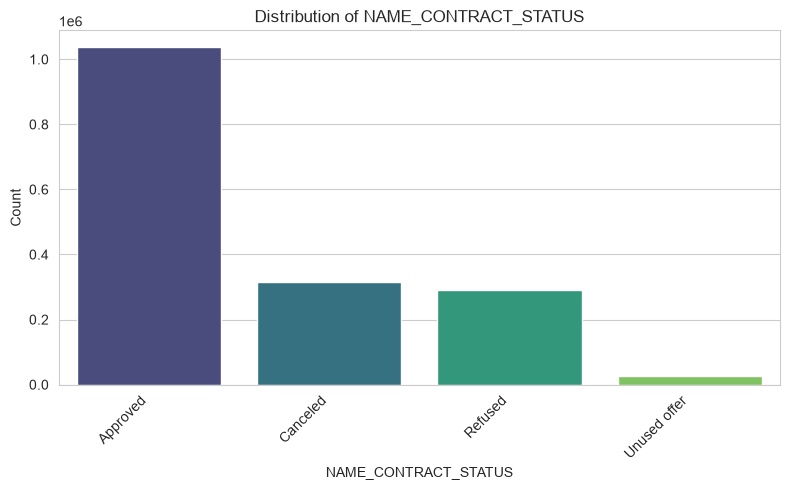

2026-06-12 20:51:57.799 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 15 numeric columns.


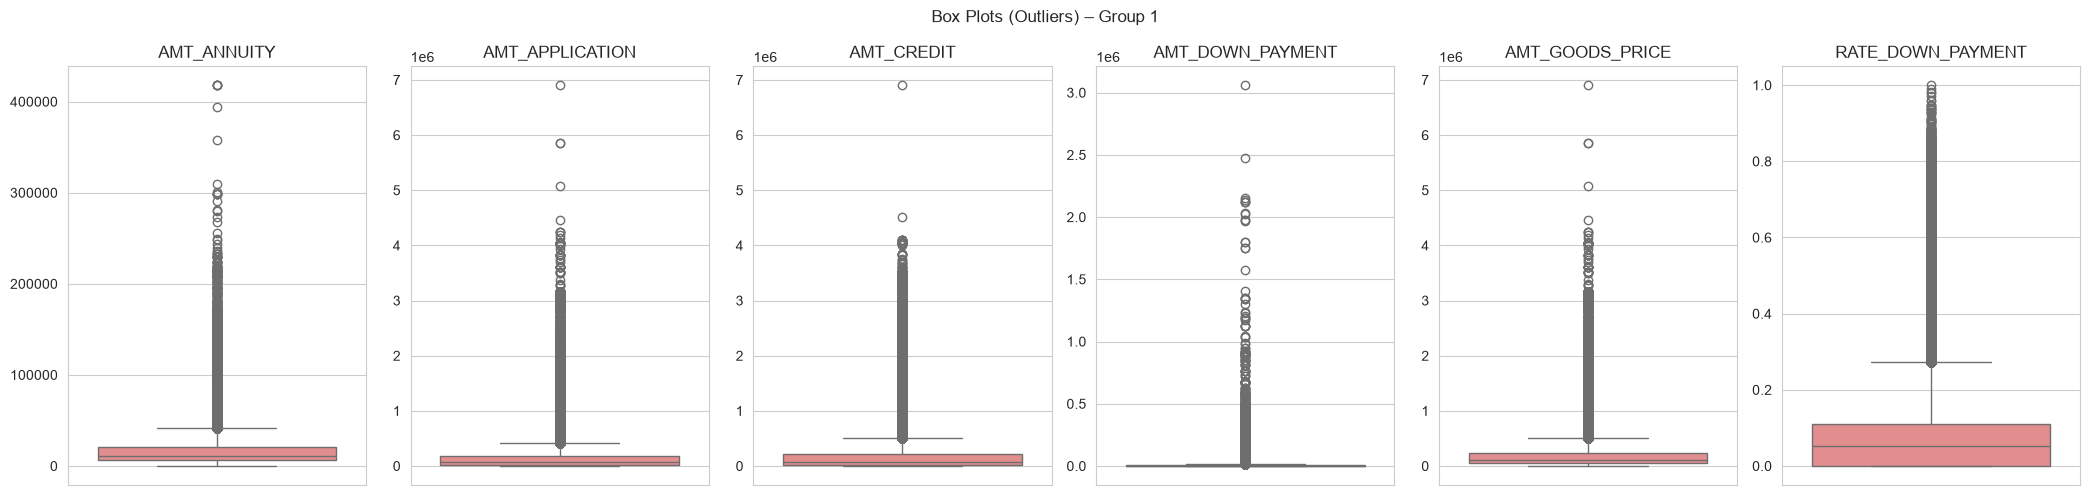

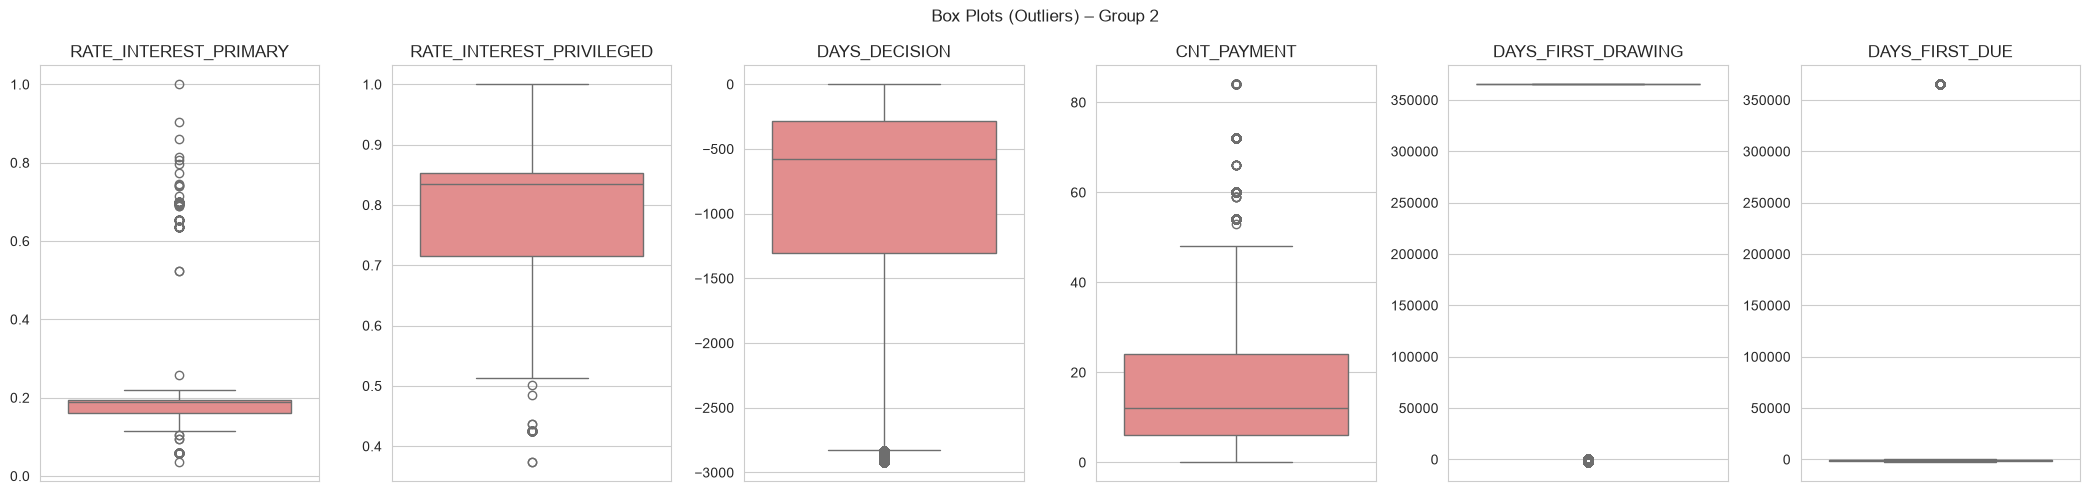

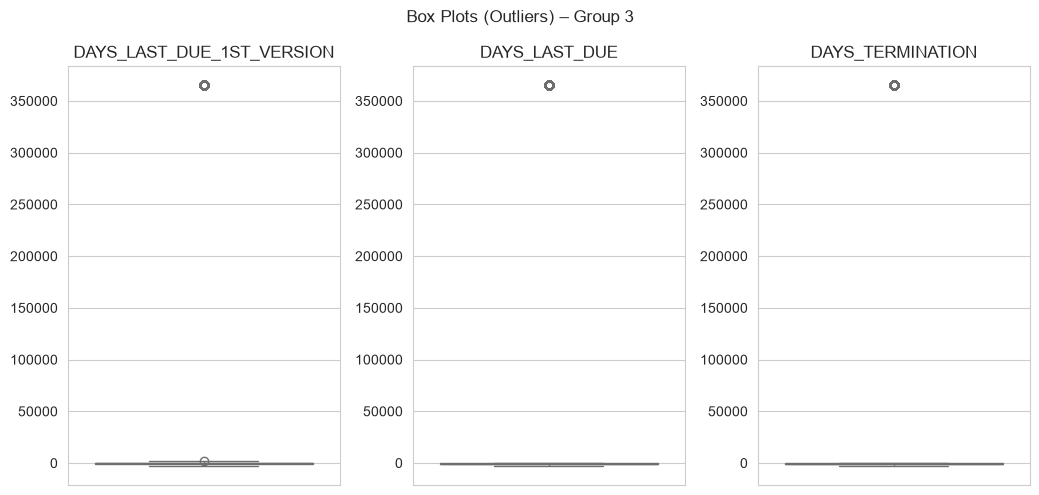

/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_13940/79553091.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette='viridis')


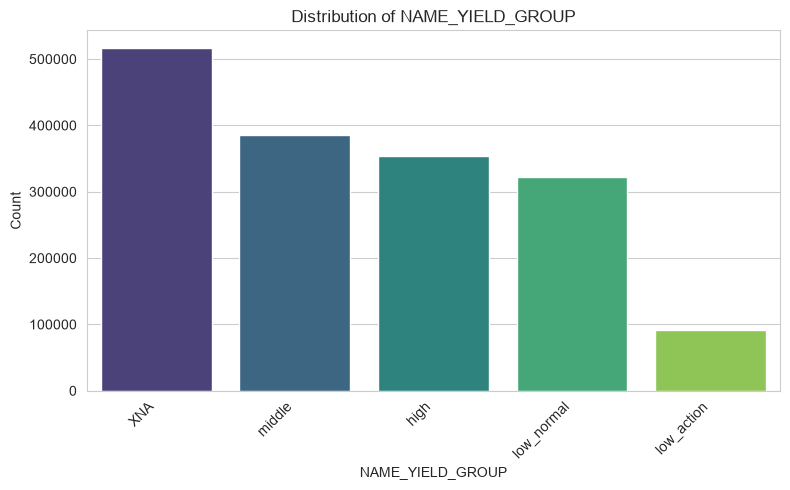

2026-06-12 20:52:14.529 | INFO     | __main__:<module>:27 - previous_application.csv EDA completed.


In [20]:
# -----------------------------------------------------------------
# previous_application.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: previous_application.csv")
logger.info("=" * 60)

df_prev = preprocessor.load_data(f"{data_dir}previous_application.csv")

eda.show_column_info(df_prev)
missing_prev = eda.show_missing_values(df_prev)
eda.show_numeric_stats(df_prev)

# Contract status distribution (approved / refused / cancelled)
eda.plot_distribution(df_prev, 'NAME_CONTRACT_STATUS')

prev_num_cols = ['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT',
                 'AMT_GOODS_PRICE', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
                 'RATE_INTEREST_PRIVILEGED', 'DAYS_DECISION', 'CNT_PAYMENT',
                 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
                 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
eda.boxplot_numeric(df_prev, columns=prev_num_cols)

# Check imbalance on other categoricals, e.g. NAME_YIELD_GROUP
eda.plot_distribution(df_prev, 'NAME_YIELD_GROUP')

logger.info("previous_application.csv EDA completed.")

2026-06-13 18:28:21.931 | INFO     | __main__:<module>:4 - ============================================================
2026-06-13 18:28:21.932 | INFO     | __main__:<module>:5 - EDA: installments_payments.csv
2026-06-13 18:28:21.932 | INFO     | __main__:<module>:6 - ============================================================
2026-06-13 18:28:21.933 | INFO     | scripts.preprocess:load_data:46 - Attempting to load data from ../../data/installments_payments.csv
2026-06-13 18:28:26.884 | INFO     | scripts.preprocess:load_data:53 - Successfully loaded data with shape (13605401, 8)
2026-06-13 18:28:26.937 | INFO     | __main__:show_column_info:13 - ===== Column Data Types =====
2026-06-13 18:28:26.940 | INFO     | __main__:show_column_info:19 - Numerical columns (8): ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']
2026-06-13 18:28:26.940 | INFO     | __main__:show_column_info:20 - C

float64    5
int64      3
Name: count, dtype: int64


            Column  Missing  Percentage
DAYS_ENTRY_PAYMENT     2905        0.02
       AMT_PAYMENT     2905        0.02


2026-06-13 18:28:32.231 | INFO     | __main__:boxplot_numeric:106 - Plotting box plots for 5 numeric columns.


                             count        mean        std        min         25%         50%         75%         max      median   skew  kurtosis
SK_ID_PREV              13605401.0  1903364.97  536202.91  1000001.0  1434191.00  1896520.00  2369094.00  2843499.00  1896520.00   0.04     -1.22
SK_ID_CURR              13605401.0   278444.88  102718.31   100001.0   189639.00   278685.00   367530.00   456255.00   278685.00  -0.00     -1.20
NUM_INSTALMENT_VERSION  13605401.0        0.86       1.04        0.0        0.00        1.00        1.00      178.00        1.00   9.59    259.61
NUM_INSTALMENT_NUMBER   13605401.0       18.87      26.66        1.0        4.00        8.00       19.00      277.00        8.00   2.50      6.71
DAYS_INSTALMENT         13605401.0    -1042.27     800.95    -2922.0    -1654.00     -818.00     -361.00       -1.00     -818.00  -0.63     -0.80
DAYS_ENTRY_PAYMENT      13602496.0    -1051.11     800.59    -4921.0    -1662.00     -827.00     -370.00       -1.00     -82

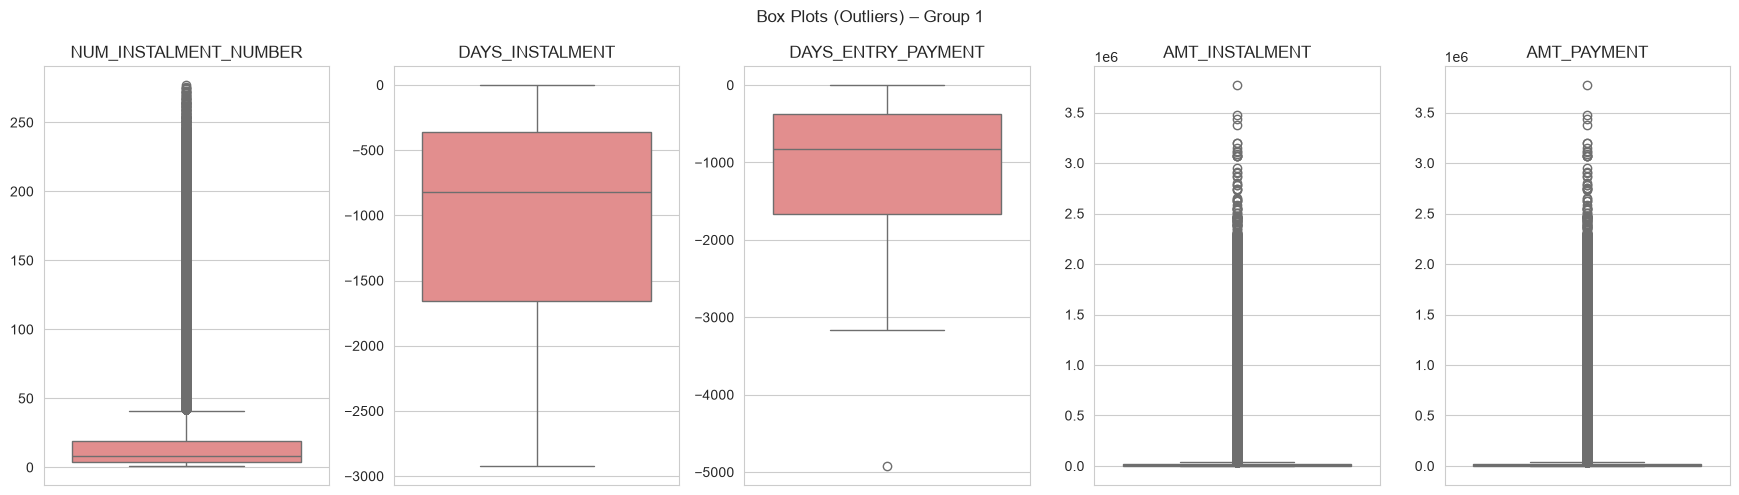

2026-06-13 18:29:17.990 | INFO     | __main__:<module>:21 - Created PAYMENT_DELAY for installments (positive = late).


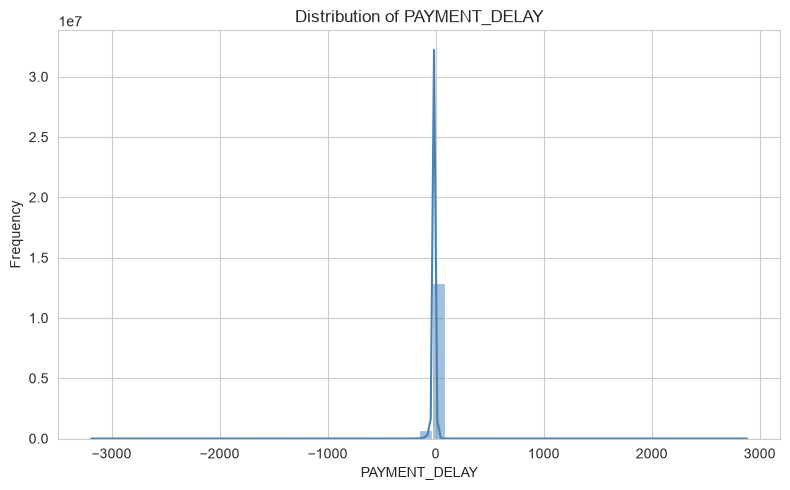

2026-06-13 18:29:28.923 | INFO     | __main__:<module>:24 - installments_payments.csv EDA completed.
2026-06-13 18:29:28.924 | INFO     | __main__:show_numeric_stats:55 - ===== Numeric Column Statistics =====


                             count        mean        std        min         25%         50%         75%         max      median   skew  kurtosis
SK_ID_PREV              13605401.0  1903364.97  536202.91  1000001.0  1434191.00  1896520.00  2369094.00  2843499.00  1896520.00   0.04     -1.22
SK_ID_CURR              13605401.0   278444.88  102718.31   100001.0   189639.00   278685.00   367530.00   456255.00   278685.00  -0.00     -1.20
NUM_INSTALMENT_VERSION  13605401.0        0.86       1.04        0.0        0.00        1.00        1.00      178.00        1.00   9.59    259.61
NUM_INSTALMENT_NUMBER   13605401.0       18.87      26.66        1.0        4.00        8.00       19.00      277.00        8.00   2.50      6.71
DAYS_INSTALMENT         13605401.0    -1042.27     800.95    -2922.0    -1654.00     -818.00     -361.00       -1.00     -818.00  -0.63     -0.80
DAYS_ENTRY_PAYMENT      13602496.0    -1051.11     800.59    -4921.0    -1662.00     -827.00     -370.00       -1.00     -82

In [7]:
# -----------------------------------------------------------------
# installments_payments.csv
# -----------------------------------------------------------------
logger.info("=" * 60)
logger.info("EDA: installments_payments.csv")
logger.info("=" * 60)

df_inst = preprocessor.load_data(f"{data_dir}installments_payments.csv")

eda.show_column_info(df_inst)
missing_inst = eda.show_missing_values(df_inst)
eda.show_numeric_stats(df_inst)

# Numeric columns: the installment amounts and timing
inst_num_cols = ['NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
                 'AMT_INSTALMENT', 'AMT_PAYMENT']
eda.boxplot_numeric(df_inst, columns=inst_num_cols)

# We can also look at the difference between due date and actual payment:
df_inst['PAYMENT_DELAY'] = df_inst['DAYS_ENTRY_PAYMENT'] - df_inst['DAYS_INSTALMENT']
logger.info("Created PAYMENT_DELAY for installments (positive = late).")
eda.plot_distribution(df_inst, 'PAYMENT_DELAY')

logger.info("installments_payments.csv EDA completed.")
eda.show_numeric_stats(df_inst)